In [1]:
from dataclasses import dataclass
from typing import Any, Optional
import warnings

import pandas as pd
import numpy as np
from scipy import optimize
from scipy import stats
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.append("..")
from FluxFox import postproc
from FluxFox.postproc.utils import compute_isday

import numpy as np
import pandas as pd

wd = Path(".")
    
cpk = pd.read_parquet(wd / "data" / "cpk.parquet")
float_cols = cpk.select_dtypes(include=["float"]).columns
cpk.loc[:, float_cols] = cpk.loc[:, float_cols].astype("float32")
lat, lon, elev = 41.3966, -106.8024, 2069.0

cpk["rho_a"] = cpk["PA"]*1000 / (287.05 * (cpk["TA"]+273.15))
storage = postproc.compute_single_point_storage_flux(
    cpk,
    rho_col = "rho_a",
    co2_col = "CO2",
    h2o_col = "H2O",
    t_col = "TA",
    co2_zm = 3.0,
    h2o_zm = 3.0,
    t_zm = 3.0
)
cpk["SC"] = storage["SC"]
cpk["SH2O"] = storage["SH2O"]
cpk["SLE"] = storage["SLE"]
cpk["SH"] = storage["SH"]
cpk["NEE"] = cpk["FC"] + cpk["SC"]  # storage-corrected NEE

raw = cpk.copy()

isday = compute_isday(cpk.index, lat, lon, elev)

# despike
spike_flag = postproc.despike_mad_papale_2006(cpk, isday, list(cpk))
cpk = cpk.where(spike_flag)

despiked = cpk.copy()

# ustar filter
ustar_res = postproc.ustar_papale_2006(cpk, isday, "TA", "USTAR", "NEE", n_ustar_classes=15, plateau_pct = 0.92, n_ta_classes=5)
cpk.loc[~ustar_res.flag, ["NEE", "H", "LE", "FC"]] = np.nan

ustar_filtered = cpk.copy()

# gapfill
gapfill_result = postproc.gapfill_xgb_liu_2025(
    cpk, "NEE",
    ta_col="TA",
    ppfd_col="PPFD_IN",
    vpd_col="VPD_PI",
    tsoil_col="TS_1_1_1",
    swc_col="SWC_1_1_1",
    extra_predictor_cols=["WD"],
    n_missing_allowed=1,
    random_state=8472,
    verbose=True,
    
    hyper_train_frac=0.13,  # 0.3
    hyper_test_frac=0.05,  # 0.1
    n_bayes_iter=15,  #50
    cv_folds=4,  # 5
)
cpk.loc[:, "NEE"] = gapfill_result.filled
gapfilled = cpk.copy()


[xgb_gapfill] 86517 rows total | 57545 target gaps to fill | 22160 rows usable for training | 6812 non-gap rows dropped for excess missing predictors
[xgb_gapfill] hyperparameter search: 2880 train / 1108 test rows, 15 Bayes iterations, 4-fold CV scoring


/Users/alex/Library/CloudStorage/OneDrive-UniversityofWyoming/Work/UWyo/Research/PostProc/tests/../FluxFox/postproc/ustar.py:202: UserWarning: R(U*,TA) = 0.47 > 0.40 for TA class [-1.62, 9.27]. Skipping
  warnings.warn(f"R(U*,TA) = {abs(corr):.2f} > {ustar_ta_corr_cutoff:.2f} for TA class [{ta_group[ta_col].min():.2f}, {ta_group[ta_col].max():.2f}]. Skipping")


[xgb_gapfill] best hyperparameters: {'l2_regularization': 0.0001, 'learning_rate': 0.10971639209458427, 'max_depth': 9, 'max_iter': 449, 'max_leaf_nodes': 25, 'min_samples_leaf': 5}
[xgb_gapfill] held-out hyper_test RMSE: 0.8198
[xgb_gapfill] final model test scores: RMSE=0.6820, R2=0.8725, bias=-0.0101 (n_test=4432)
[xgb_gapfill] refitting final model on all usable rows


/Users/alex/Library/CloudStorage/OneDrive-UniversityofWyoming/Work/UWyo/Research/PostProc/tests/../FluxFox/postproc/gapfill.py:392: UserWarning: [xgb_gapfill] WARNING: 42030 gap rows exceed the n_missing_allowed=1 predictor NaN tolerance and cannot be filled; they remain NaN.
  warnings.warn(msg)


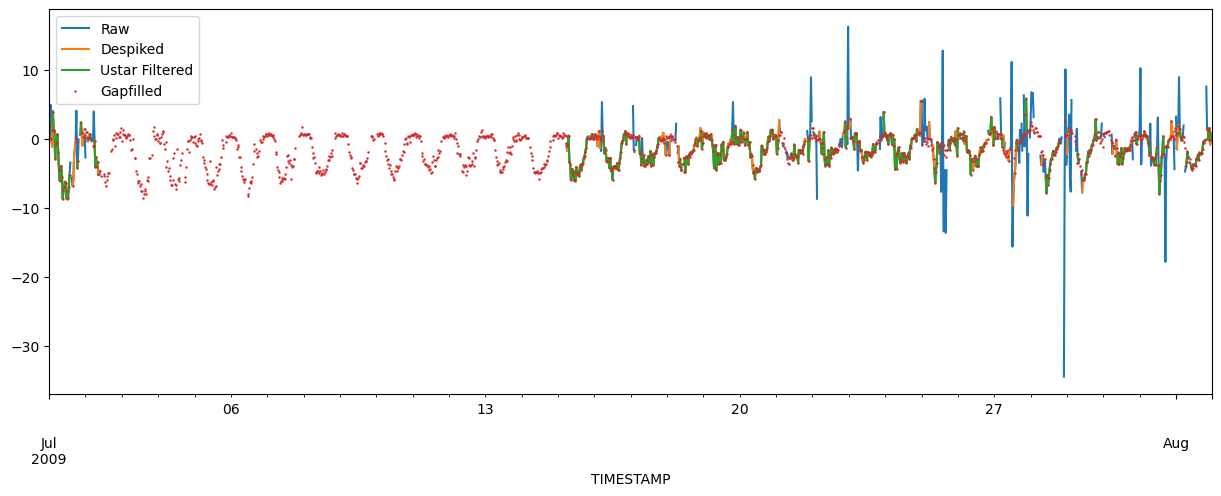

In [2]:
start, end = "2009-07-01", "2009-08-01"
raw.loc[start:end, "NEE"].plot(figsize=(15,5), label="Raw")
despiked.loc[start:end, "NEE"].plot(label="Despiked")
ustar_filtered.loc[start:end, "NEE"].plot(label="Ustar Filtered")
gapfilled.loc[start:end, "NEE"].plot(label="Gapfilled", style='o', markersize=0.75)
plt.legend()

In [203]:
# Author: Alex Fox
# Created: 2026-06-17

"""
Partitioning utilities
"""

from dataclasses import dataclass
from typing import Any, Literal, Optional
import warnings

import pandas as pd
import numpy as np
from scipy import optimize

from FluxFox.postproc.utils import _check_common_args, month_to_season, season_to_month

# Hard-coded limits on parameters
_R_REF_LOWER = 0.0
_R_REF_UPPER = np.inf
_E0_LOWER = 50.0
_E0_UPPER = 400.0
_ALPHA_LOWER = 0.0
_ALPHA_UPPER = 0.6
_BETA_0_LOWER = 0.0
_BETA_0_UPPER = 250
_K_LOWER = 0.0
_K_UPPER = np.inf


def _lloyd_taylor_1994(T: np.ndarray, R_ref: float, E0: float) -> np.ndarray:
    """
    Lloyd and Taylor (1994) model of ecosystem respiration as a function of temperature.
    """
    T_ref = 10 + 273.15
    T0 = -46.02 + 273.15
    return R_ref * np.exp(E0 * (1. / (T_ref - T0) - 1. / (T - T0 + 273.15)))

def _fit_lt94(x_data: np.ndarray, y_data: np.ndarray, fix_E0: Optional[float] = None) -> Any:
    def objective(p: np.ndarray) -> float:
        if fix_E0 is not None:
            E0 = fix_E0
            R_ref = p
        else:
            R_ref, E0 = p
        y_hat = _lloyd_taylor_1994(x_data, R_ref=R_ref, E0=E0)
        # return np.sum((y_data - y_hat) ** 2)
        return np.sum(np.abs(y_data - y_hat))
    
    R_ref_init = max(0, np.nanmean(y_data))
    E0_init = 100.0
    if fix_E0 is not None:
        res = optimize.minimize(
            objective,
            x0=np.array([R_ref_init]), bounds=optimize.Bounds(lb=[_R_REF_LOWER], ub=[_R_REF_UPPER]), 
            method="Nelder-Mead", 
            options={'maxiter': 10_000, 'xatol': 1e-6, 'fatol':1e-6}
        )
    else:
        res = optimize.minimize(
            objective,
            x0=np.array([R_ref_init, E0_init]), bounds=optimize.Bounds(lb=[_R_REF_LOWER, _E0_LOWER], ub=[_R_REF_UPPER, _E0_UPPER]), 
            method="Nelder-Mead", 
            options={'maxiter': 10_000, 'xatol': 1e-6, 'fatol':1e-6}
        )
    return res

@dataclass
class FalgeResult:
    GPP: pd.Series
    Reco: pd.Series
    res: optimize.OptimizeResult

def gpp_night_falge_2001(
    df: pd.DataFrame,
    isday: pd.Series,
    nee_col: str,
    t_col: str,
)-> FalgeResult:
    r"""
    Partitioning of NEE into GPP and Reco based on 
    Falge et al. (2001). "Gap filling strategies for defensible annual sums of net ecosystem exchange," Agricultural and Forest Meteorology

    This is a "quick and dirty" method, using nighttime NEE to estimate ecosystem respiration ($R_{eco}$) and then partitioning daytime NEE into GPP and Reco based on temperature observations, as in Lloyd and Taylor (1994).
    This method is largely outdated.

    $$
    R_{eco} = R_{ref} * \exp\left( E_0  \left( \frac{1}{T_ref - T_0} - \frac{1}{T - T_0} \right) \right)
    $$

    where $T_{ref}$=10°C and $T_0$=-46.02°C. $E_0$ and $R_{ref}$ are fitted parameters.


    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing NEE data to be partitioned, along with air temperature.
        Must have a DatetimeIndex.
    isday: pd.Series
        Boolean series indicating daytime observations. Must align with df. utils.compute_isday can be used to generate this series.
    nee_col: str
        Name of the column containing NEE (CO2 flux, ideally storage-corrected) data. µmol m-2 s-1 required.
    t_col: str
        Name of the column containing air temperature (or soil temperature) data. Degrees Celsius required.
    
    Returns
    -------
    FalgeResult
        Object containing partitioned GPP and Reco, and the optimization result (from scipy.optimize.minimize)
    """
    
    _check_common_args(df, isday)
    if not df.index.is_monotonic_increasing:
        df = df.sort_index()
        isday = isday.sort_index()

    nighttime_NEE = df.loc[~isday, [nee_col, t_col]].dropna()
    res = _fit_lt94(x_data=nighttime_NEE[t_col], y_data=nighttime_NEE[nee_col])
    
    R_ref, E0 = res.x

    if R_ref <= _R_REF_LOWER or R_ref >= _R_REF_UPPER or E0 <= _E0_LOWER or E0 >= _E0_UPPER:
        warnings.warn(f"Fitted R_ref ({R_ref}) or E0 ({E0}) are outside expected bounds. Check data quality, fitting parameters, and fitting procedure.")
    
    df_out = pd.DataFrame(index=df.index)
    df_out['Reco'] = _lloyd_taylor_1994(df[t_col].values, R_ref=R_ref, E0=E0)
    df_out['GPP'] = -df[nee_col] + df_out['Reco']

    # cap to non-negative values
    df_out['GPP'] = df_out['GPP'].clip(lower=0)
    df_out['Reco'] = df_out['Reco'].clip(lower=0)
    
    return FalgeResult(
        GPP=df_out['GPP'],
        Reco=df_out['Reco'],
        res=res
    )
    
@dataclass
class ReichsteinResult:
    """
    Diagnostics for the Reichstein et al. (2005) partitioning method.
    Contains the fitted GPP and Reco timeseries, E0 parameter, the time-varying R_ref estimates, and diagnostic DataFrames for both E0 and R_ref displaying the optimize.OptimizeResult objects (Nelder-Mead method)
    """
    GPP: pd.Series
    Reco: pd.Series
    params: pd.DataFrame
    E0_diag: pd.DataFrame
    R_ref_diag: pd.DataFrame

def gpp_night_reichstein_2005(
    df: pd.DataFrame,
    isday: pd.Series,
    nee_col: str,
    t_col: str,
    E0_window_width_days: int = 14,
    R_ref_window_width_days: int = 7,
    n_best_E0: int = 3,
    min_datapoints: int = 6,
    min_temp_range: float = 5.0,
    num_seasons: int = 1,
)-> ReichsteinResult:
    r"""
    Partitioning of NEE into GPP and Reco based on 
    Reichstein et al. (2005). "On the separation of net ecosystem exchange into assimilation and ecosystem respiration: review and improved algorithm," Global Change Biology

    This method is a more sophisticated approach compared to Falge 2001, as it accounts for temporal variability in ecosystem respiration, but is still solely reliant on nighttime NEE to predict daytime GPP.

    This method fits a Lloyd-Taylor model to nighttime NEE data to estimate ecosystem respiration parameters in 2 stages:
    1. Estimate E0:
        Within a moving window of size `E0_window_width_days`, the E0 parameter is estimated from nighttime NEE data. Using a LOO-CV approach, the uncertainty of E0 within each window is assessed.
        Windows with sample size less than `min_datapoints` or temperature range less than `min_temp_range` are skipped.
        Then, the best `n_best_E0` estimates (based on the smallest standard error) are selected to represent the E0 parameter, and averaged.
    2. Estimate R_ref:
        Within a moving window of size `R_ref_window_width_days`, the R_ref parameter is estimated from nighttime NEE data using the previously determined E0.
        Windows with sample size less than `min_datapoints` or temperature range less than `min_temp_range` are skipped.
        The resulting R_ref estimates are then linearly interpolated.
    
    Reco is then calculated using the Lloyd Taylor model (as a function of temperature) with the estimated E0 and interpolated R_ref for all timepoints (including nighttime ones).

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing NEE data to be partitioned, along with air temperature.
        Must have a DatetimeIndex.
    isday : pd.Series
        Boolean series indicating daytime observations. Must align with df. utils.compute_isday can be used to generate this series.
    nee_col: str
        Name of the column containing NEE (CO2 flux, ideally storage-corrected) data. µmol m-2 s-1 required.
    t_col: str
        Name of the column containing air temperature (or soil temperature) data. Degrees Celsius required.
    E0_window_width_days : int, default=14
        Width of the moving window (in days) used to estimate E0. Changing this window can help resolve issues where no valid E0 estimates are obtained within a given season.
    R_ref_window_width_days : int, default=7
        Width of the moving window (in days) used to estimate R_ref
    n_best_E0 : int, default=3
        Number of best E0 estimates to consider based on the smallest standard error. Decreasing this number will make the estimate more selective, potentially resolving issues where not enough valid E0 estimates are obtained, but increasing uncertainty.
    min_datapoints : int, default=6
        Minimum number of data points required within a moving window to perform the estimation.
    min_temp_range : float, default=5.0
        Minimum temperature range (in °C) required within a moving window to perform the estimation.
    num_seasons : int, default=1
        Number of seasons to divide the data into for E0 estimation. Typically 1 for a single season, increase this value if you suspect temporal variation in E0 within the year that warrants finer seasonal resolution.
    Returns
    -------
    ReichsteinResult
        Object containing partitioned GPP and Reco, the time-varying E0 and R_ref estimates, and diagnostic DataFrames for both E0 and R_ref displaying the optimize.OptimizeResult objects (Nelder-Mead method).
    """

    _check_common_args(df, isday)
    if not df.index.is_monotonic_increasing:
        df = df.sort_index()
        isday = isday.sort_index()
    if not E0_window_width_days > 0:
        raise ValueError("E0_window_width_days must be positive.")
    if not int(E0_window_width_days) == E0_window_width_days:
        raise ValueError("E0_window_width_days must be an integer.")
    if not R_ref_window_width_days > 0:
        raise ValueError("R_ref_window_width_days must be positive.")
    if not int(R_ref_window_width_days) == R_ref_window_width_days:
        raise ValueError("R_ref_window_width_days must be an integer.")
    if not n_best_E0 > 0:
        raise ValueError("n_best_E0 must be positive.")
    if not int(n_best_E0) == n_best_E0:
        raise ValueError("n_best_E0 must be an integer.")
    if not min_datapoints > 0:
        raise ValueError("min_datapoints must be positive.")
    if not int(min_datapoints) == min_datapoints:
        raise ValueError("min_datapoints must be an integer.")
    if not min_temp_range > 0:
        raise ValueError("min_temp_range must be positive.")
    E0_window_width_days = int(E0_window_width_days)
    R_ref_window_width_days = int(R_ref_window_width_days)
    n_best_E0 = int(n_best_E0)
    min_datapoints = int(min_datapoints)
    num_seasons = int(num_seasons)

    nighttime_NEE = df.loc[~isday, [nee_col, t_col]].dropna()

    # estimate E0 from a collection of short nighttime windows. Estimate 1 value per season.
    years, seasons, E0s = [], [], []
    for yrssn, group in nighttime_NEE[[t_col, nee_col]].groupby([nighttime_NEE.index.year, month_to_season(nighttime_NEE.index.month, num_seasons)]):
        year, season = yrssn
        E0_diag = []
        for idx, window in group.groupby(pd.Grouper(freq=f"{E0_window_width_days}D")):
            window = window.dropna()
            npoints = window.shape[0]
            trange = window[t_col].max() - window[t_col].min()
            if npoints < min_datapoints or trange < min_temp_range:
                continue
            try:
                res = _fit_lt94(x_data=window[t_col].to_numpy(), y_data=window[nee_col].to_numpy())
            except Exception as e:
                warnings.warn(f"E0 fitting failed for window starting at {idx}: {e}")
                continue
            success, status, fun, R_ref, E0, nit, nfev = res.success, res.status, res.fun, *res.x, res.nit, res.nfev
            E0_diag.append([idx, success, status, fun, R_ref, E0, nit, nfev, npoints, trange])
        E0_diag = pd.DataFrame(E0_diag, columns=['idx', 'success', 'status', 'fun', 'R_ref', 'E0', 'nit', 'nfev', 'npoints', 'trange'])
        E0_diag = E0_diag.loc[E0_diag['success']].dropna()
        
        # Handle cases where E0 could not be reliably estimated.
        if E0_diag.shape[0] < n_best_E0:
            warnings.warn(f"Not enough successful E0 fits to compute a reliable estimate. Required: {n_best_E0}, available: {E0_diag.shape[0]}")
            E0 = np.nan
        else:
            E0 = E0_diag[["E0", "fun"]].sort_values("fun").iloc[:n_best_E0].mean()["E0"]
        
        E0_oob = 0
        if E0 <= _E0_LOWER:
            warnings.warn(f"Setting E0 to {E0} for {year}, season {season}, which is the lower bound. If this happens frequently, consider adjusting your fitting parameters or reviewing the quality of your data.")
            E0 = np.nan
            E0_oob = -1
        elif E0 >= _E0_UPPER:
            warnings.warn(f"Setting E0 to {E0} for {year}, season {season}, which is the upper bound. If this happens frequently, consider adjusting your fitting parameters or reviewing the quality of your data.")
            E0 = np.nan
            E0_oob = 1

        if np.isnan(E0):
            if len(E0s):
                E0 = E0s[-1]
            elif E0_oob == -1:
                E0 = _E0_LOWER
            elif E0_oob == 1:
                E0 = _E0_UPPER
            else:
                E0 = np.nan
                warnings.warn(f"Setting E0 to NaN for {year}, season {season} because it could not be determined from previous values or bounds.")

        years.append(year)
        seasons.append(season)
        E0s.append(E0)
    E0_diag = pd.DataFrame({
        "year": years,
        "season": seasons,
        "E0": E0s
    })
    E0_diag["Date"] = pd.to_datetime(E0_diag["year"].astype(str) + "-" + season_to_month(E0_diag["season"], 4).astype(str) + "-" + "01")
    E0_diag = E0_diag.set_index("Date").sort_index().drop(columns=["season", "year"])

    # n_obs_per_day = int(86_400 // np.nanmedian(df.index.diff().total_seconds()))
    # days_per_season = (12 // num_seasons) * 31
    # limit = int(n_obs_per_day * days_per_season * 2)
    # print(days_per_season, n_obs_per_day, limit)
    E0_values = E0_diag["E0"].reindex(df.index.union(E0_diag.index)).sort_index().ffill().bfill()
    # ffill(limit=limit).bfill(limit=limit).reindex(df.index)

    # Estimate R_ref over time using the moving window approach.
    R_ref_diag = []
    for idx, window in nighttime_NEE[[t_col, nee_col]].groupby(pd.Grouper(freq=f"{R_ref_window_width_days}D")):
        E0 = E0_values.asof(idx)
        window = window.dropna()
        if window.shape[0] < min_datapoints or window[t_col].max() - window[t_col].min() < min_temp_range:
            continue
        try:
            res = _fit_lt94(x_data=window[t_col].to_numpy(), y_data=window[nee_col].to_numpy(), fix_E0=E0)
        except Exception as e:
            warnings.warn(f"R_ref fitting failed for window starting at {idx}: {e}")
            continue
        success, status, fun, R_ref, nit, nfev = res.success, res.status, res.fun, *res.x, res.nit, res.nfev
        R_ref_diag.append([idx, success, status, fun, R_ref, E0, nit, nfev, window.shape[0], window[t_col].max() - window[t_col].min()])
    R_ref_diag = pd.DataFrame(R_ref_diag, columns=['idx', 'success', 'status', 'fun', 'R_ref', 'E0', 'nit', 'nfev', 'npoints', 'trange']).set_index("idx")
    
    R_ref_diag = R_ref_diag.loc[R_ref_diag['success']]
    R_ref = R_ref_diag["R_ref"]
    R_ref = R_ref.reindex(df.index).interpolate(method="time")
    if R_ref.quantile(0.95) < 1e-6:
        warnings.warn(f">=95% of fitted R_ref ({R_ref.quantile(0.95)}) values are very small. Check data quality and fitting procedure. This is often caused by NEE being biased negative, especially at night.")
    elif R_ref.quantile(0.05) < 1e-6:
        warnings.warn(f">=5% of fitted R_ref ({R_ref.quantile(0.05)}) values are very small. Check data quality and fitting procedure. This is often caused by NEE being biased negative, especially at night.")

    # apply lloyd taylor
    R_eco = _lloyd_taylor_1994(T=df[t_col], R_ref=R_ref, E0=E0_values)
    GPP = -df[nee_col] + R_eco

    # clip to 0
    GPP = GPP.clip(lower=0)

    results = ReichsteinResult(
        GPP=GPP,
        Reco=R_eco,
        params=pd.DataFrame({
            "E0": E0_values,
            "R_ref": R_ref
        }).astype(np.float32),
        E0_diag=E0_diag,
        R_ref_diag=R_ref_diag
    )

    return results

def _lasslop_2010_eq4(R_g: np.ndarray, T: np.ndarray, VPD: np.ndarray, alpha: float, beta_0: float, k: float, R_ref: float, E0: float) -> np.ndarray:
    """
    Lasslop et al. 2010 equation 4 for daytime GPP estimation.
    """
    VPD_0 = 10  # hPa
    beta = np.where(VPD < VPD_0, beta_0,  beta_0 * np.exp(-k * (VPD - VPD_0)))
    GPP = alpha*beta*R_g / (alpha*R_g + beta)
    Reco = _lloyd_taylor_1994(T=T, R_ref=R_ref, E0=E0)
    NEE = Reco - GPP
    return NEE

def _fit_lasslop_eq4(x_data: np.ndarray, y_data: np.ndarray, E0: float, R_ref_init: Optional[float] = None) -> Any:
    R_g = x_data[:, 0]
    T = x_data[:, 1]
    VPD = x_data[:, 2]
    def objective(p: np.ndarray) -> float:
        alpha, beta_0, k, R_ref = p
        y_hat = _lasslop_2010_eq4(R_g, T, VPD, alpha, beta_0, k, R_ref, E0)
        # return np.sum((y_data - y_hat) ** 2)
        return np.sum(np.abs(y_data - y_hat))

    alpha_init = 0.01
    beta_0_init = max(10, np.abs(np.nanquantile(y_data, 0.03) - np.nanquantile(y_data, 0.97)))
    k_init = 0
    if R_ref_init is None or not np.isfinite(R_ref_init) or R_ref_init <= 0:
        R_ref_init = max(1.0, np.nanmean(np.abs(y_data)))

    res = optimize.minimize(
        objective,
        x0=np.array([alpha_init, beta_0_init, k_init, R_ref_init]), 
        bounds=optimize.Bounds(
            lb=[_ALPHA_LOWER, _BETA_0_LOWER, _K_LOWER, _R_REF_LOWER], 
            ub=[_ALPHA_UPPER, _BETA_0_UPPER, _K_UPPER, _R_REF_UPPER]
        ), 
        method="Nelder-Mead", 
        options={'maxiter': 10_000, 'xatol': 1e-6, 'fatol':1e-6}
    )
    return res

@dataclass
class LasslopResult:
    GPP: pd.Series
    Reco: pd.Series
    params: pd.DataFrame
    nighttime_diag: pd.DataFrame
    daytime_diag: pd.DataFrame

def gpp_day_lasslop_2010(
    df: pd.DataFrame,
    isday: pd.Series,
    nee_col: str,
    t_col: str,
    swin_col: str,
    vpd_col: str,
    night_window_width_days: int = 14,
    day_window_width_days: int = 4,
    n_best_E0: int = 3,
    min_night_datapoints: int = 6,
    min_night_temp_range: float = 5.0,
    min_day_datapoints: int = 6,
    min_day_temp_range: float = 5.0,
    min_day_vpd_range: float = 0.5,
    num_seasons: int = 1,
)-> LasslopResult: 
    r"""
    Perform daytime GPP partitioning using the Lasslop et al. 2010 method.

    This method estimates GPP using a "daytime method," where daytime NEE is treated as a function of incoming radiation, temperature, and VPD.

    The "daytime method" recognizes that daytime Reco will not behave identically to nighttime Reco, and thus requires separate estimation using daytime data.
    This is done by modeling NEE as NEE = GPP + Reco, where GPP is a function of VPD and incoming radiation and Reco is a function of temperature.

    $$
    \text{NEE}(SW_{in}, T, VPD) = \text{GPP}(SW_{in}, VPD) + \text{R}_{eco}(T) \\ 
    \text{R}_{eco}(T) = R_{ref}\exp\left(E_0\left(\frac{1}{T_{ref}-T_0}-\frac{1}{T-T_0}\right)\right) \\ 
    \text{GPP}(SW_{in}, VPD) = \frac{\alpha \beta_0(VPD) SW_{in}}{\alpha SW_{in} + \beta(VPD)} \\ 
    \beta(VPD) = \begin{cases} beta_0 & \text{if } VPD < VPD_0 \\ beta_0 \exp(-k (VPD - VPD_0)) & \text{otherwise} \end{cases}
    $$

    The method is as follows:
    1. Estimate E0 from nighttime data using the Reichstein et al. 2005 method (see :func:`gpp_night_reichstein_2005`). E0 is allowed to vary seasonally.
    2. Using E0 estimated from step 1, estimate k, alpha, beta_0, and R_ref from daytime data in `day_window_width_days`-day windows.
    3. Compute Reco using the Lloyd-Taylor model and the fitted parameters (R_ref and E0).
    4. Compute GPP using the Lasslop model as -(NEE(SW_in, T, VPD) - Reco).

    Parameters
    ----------
    df: pd.DataFrame
        Input data containing NEE, temperature, incoming radiation, and VPD. Must have a DatetimeIndex and columns for NEE, temperature, incoming radiation, and VPD.
    isday: pd.Series
        Boolean series indicating daytime observations. Must align with the index of `df`.
    nee_col: str
        Name of the column containing NEE (CO2 flux, ideally storage-corrected) observations. µmol m-2 s-1 required.
    t_col: str
        Name of the column containing temperature observations. Must be in degrees Celsius.
    swin_col: str
        Name of the column containing incoming radiation observations. Can also be PPFD. Unit-agnostic.
    vpd_col: str
        Name of the column containing VPD observations. Must be in hPa.
    night_window_width_days: int, optional
        Number of days to use for estimating nighttime E0. Default is 14. Adjusting this window can help resolve issues where no valid E0 estimates are obtained within a given season, but may increase uncertainty if set too small.
    day_window_width_days: int, optional
        Number of days to use for estimating daytime parameters. Default is 4.
    n_best_E0: int, optional
        Number of best E0 estimates to consider. Default is 3. Decreasing this number will make the estimate more selective, potentially resolving issues where not enough valid E0 estimates are obtained, but increasing uncertainty.
    min_night_datapoints: int, optional
        Minimum number of nighttime data points required for E0 estimation. Default is 6.
    min_night_temp_range: float, optional
        Minimum temperature range required for nighttime E0 estimation. Default is 5.0.
    min_day_datapoints: int, optional
        Minimum number of daytime data points required for parameter estimation. Default is 6.
    min_day_temp_range: float, optional
        Minimum temperature range required for daytime parameter estimation. Default is 5.0.
    min_day_vpd_range: float, optional
        Minimum VPD range required for daytime parameter estimation. Default is 0.5.
    num_seasons: int, optional
        Number of seasons to divide the data into for parameter estimation. Default is 1.
    
    Returns
    -------
    LasslopResult
        Contains the estimated GPP and Reco time series, as well as the fitted parameters and diagnostic information for both nighttime and daytime fits.

    """

    # quick check on inputs
    if (df[swin_col] < -50).any() or (df[swin_col] > 3000).any():
        warnings.warn(f"Incoming radiation values out of expected range: min={df[swin_col].min()}W m-2 (or µmol m-2 s-1), max={df[swin_col].max()} W m-2 (or µmol m-2 s-1)")
    if (df[t_col].min() < -60) or (df[t_col].max() > 100):
        warnings.warn(f"Temperature values out of expected range: min={df[t_col].min()}°C, max={df[t_col].max()}°C")
    if (df[vpd_col].min() < -0.5) or (df[vpd_col].max() > 80):
        warnings.warn(f"VPD values out of expected range: min={df[vpd_col].min()} hPa, max={df[vpd_col].max()} hPa")
    if (df[vpd_col].max() < 10):
        warnings.warn(f"VPD values are unusually low: max={df[vpd_col].max()} hPa. Did you remember to convert to hPa?")

    # E0 is estimated from nighttime data. Re-use the gpp_night_reichstein_2005 function to obtain it.
    night_results = gpp_night_reichstein_2005(
        df=df,
        isday=isday,
        nee_col=nee_col,
        t_col=t_col,
        E0_window_width_days=night_window_width_days,
        R_ref_window_width_days=day_window_width_days*10,
        n_best_E0=n_best_E0,
        min_datapoints=min_night_datapoints,
        min_temp_range=min_night_temp_range,
        num_seasons=num_seasons
    )
    E0 = night_results.params["E0"]
    R_ref_night = night_results.params["R_ref"]

    daytime_NEE = df.loc[isday, [nee_col, t_col, swin_col, vpd_col]]
    daytime_diag = []
    for idx, window in daytime_NEE.groupby(pd.Grouper(freq=f"{day_window_width_days}D")):
        E0_window = E0.asof(idx)
        R_ref_window = R_ref_night.asof(idx)
        window = window.dropna()
        if window.shape[0] < min_day_datapoints:
            continue
        if window[t_col].max() - window[t_col].min() < min_day_temp_range:
            continue
        if window[vpd_col].max() - window[vpd_col].min() < min_day_vpd_range:
            continue

        try:
            res = _fit_lasslop_eq4(
                x_data=window[[swin_col, t_col, vpd_col]].to_numpy(),
                y_data=window[nee_col].to_numpy(),
                E0=E0_window,
                R_ref_init=float(R_ref_window)
            )
        except Exception as e:
            continue

        success, status, fun, alpha, beta_0, k, R_ref, nit, nfev = res.success, res.status, res.fun, *res.x, res.nit, res.nfev

        # handle failures
        # alpha: set to value of previous window. If not previous window exists and <0, set to 0.
        if not success or np.isnan(alpha):
            if len(daytime_diag):
                print("setting alpha to prev val")
                alpha = daytime_diag[-1][4]  # use alpha from previous window
            else:
                print("setting alpha to nan")
                alpha = np.nan
        
        # k: set to 0
        if not success or np.isnan(k):
            print("setting k=0")
            k = 0

        # beta_0: if negative set to zero, else the whole parameter set is not used
        if not success or np.isnan(beta_0):
            beta_0 = np.nan
            alpha = np.nan
            k = np.nan
            R_ref = np.nan
        
        # R_ref: whole parameter set is not used
        if not success or np.isnan(R_ref):
            alpha = np.nan
            beta_0 = np.nan
            k = np.nan
            R_ref = np.nan
    
        
        daytime_diag.append([idx, success, status, fun, alpha, beta_0, k, R_ref, nit, nfev])

    daytime_diag = pd.DataFrame(
        daytime_diag,
        columns=['idx', 'success', 'status', 'fun', 'alpha', 'beta_0', 'k', 'R_ref', 'nit', 'nfev']
    ).set_index("idx")

    # filter out major outliers
    float_cols = ['alpha', 'beta_0', 'k', 'R_ref']
    bad_vals = (daytime_diag[float_cols] >= daytime_diag[float_cols].quantile(0.99))
    daytime_diag[float_cols] = daytime_diag[float_cols].mask(bad_vals)

    # daytime_diag = daytime_diag.loc[daytime_diag['success']]
    # daytime_params = daytime_diag[["alpha", "beta_0", "k", "R_ref"]]
    # n_obs_per_day = int(86_400 // np.nanmedian(df.index.diff().total_seconds()))
    daytime_params = daytime_diag.reindex(df.index).interpolate(method="time").bfill().ffill()

    # calculate Reco and GPP: apply Lloyd-taylor
    R_eco = _lloyd_taylor_1994(T=df[t_col], R_ref=daytime_params['R_ref'], E0=E0)
    GPP = _lasslop_2010_eq4(
        R_g=df[swin_col],
        T=df[t_col],
        VPD=df[vpd_col],
        alpha=daytime_params['alpha'],
        beta_0=daytime_params['beta_0'],
        k=daytime_params['k'],
        R_ref=daytime_params['R_ref'],
        E0=E0
    ) - R_eco
    GPP = -GPP
    GPP = GPP.clip(lower=0)
    R_eco = R_eco.clip(lower=0)

    return LasslopResult(
        GPP=GPP,
        Reco=R_eco,
        params=pd.concat([night_results.params[["E0"]], daytime_params[["alpha", "beta_0", "k", "R_ref"]]], axis=1),
        nighttime_diag=night_results.E0_diag,
        daytime_diag=daytime_diag
    )
__all__ = ["ReichsteinResult", "FalgeResult", "LasslopResult", "gpp_night_reichstein_2005", "gpp_night_falge_2001", "gpp_day_lasslop_2010"]

In [204]:
falge_res = gpp_night_falge_2001(
    cpk, isday, "NEE", "TA"
)
falge_partition = pd.DataFrame()
falge_partition["GPP"] = falge_res.GPP
falge_partition["Reco"] = falge_res.Reco
falge_res.res

reich_res = gpp_night_reichstein_2005(
    cpk, isday, "NEE", "TA",
    n_best_E0 = 2,
    E0_window_width_days = 21,
    num_seasons = 4,
)
reich_partition = pd.DataFrame()
reich_partition["GPP"] = reich_res.GPP
reich_partition["Reco"] = reich_res.Reco

lasslop_res = gpp_day_lasslop_2010(
    cpk, isday, "NEE", "TA", "PPFD_IN", "VPD_PI",
    n_best_E0 = 2,
    night_window_width_days = 21,
    num_seasons = 4,
)
lasslop_partition = pd.DataFrame()
lasslop_partition["GPP"] = lasslop_res.GPP
lasslop_partition["Reco"] = lasslop_res.Reco

/var/folders/h1/hhwj_15n5pjc0cht5mmph_y40000gn/T/ipykernel_43626/2227108532.py:123: UserWarning: Fitted R_ref (0.15871861351974328) or E0 (400.0) are outside expected bounds. Check data quality, fitting parameters, and fitting procedure.
  warnings.warn(f"Fitted R_ref ({R_ref}) or E0 ({E0}) are outside expected bounds. Check data quality, fitting parameters, and fitting procedure.")
/var/folders/h1/hhwj_15n5pjc0cht5mmph_y40000gn/T/ipykernel_43626/2227108532.py:270: UserWarning: Setting E0 to 50.0 for 2006, season 1, which is the lower bound. If this happens frequently, consider adjusting your fitting parameters or reviewing the quality of your data.
  warnings.warn(f"Setting E0 to {E0} for {year}, season {season}, which is the lower bound. If this happens frequently, consider adjusting your fitting parameters or reviewing the quality of your data.")
/var/folders/h1/hhwj_15n5pjc0cht5mmph_y40000gn/T/ipykernel_43626/2227108532.py:263: UserWarning: Not enough successful E0 fits to compute 

(0.0, 1.0)

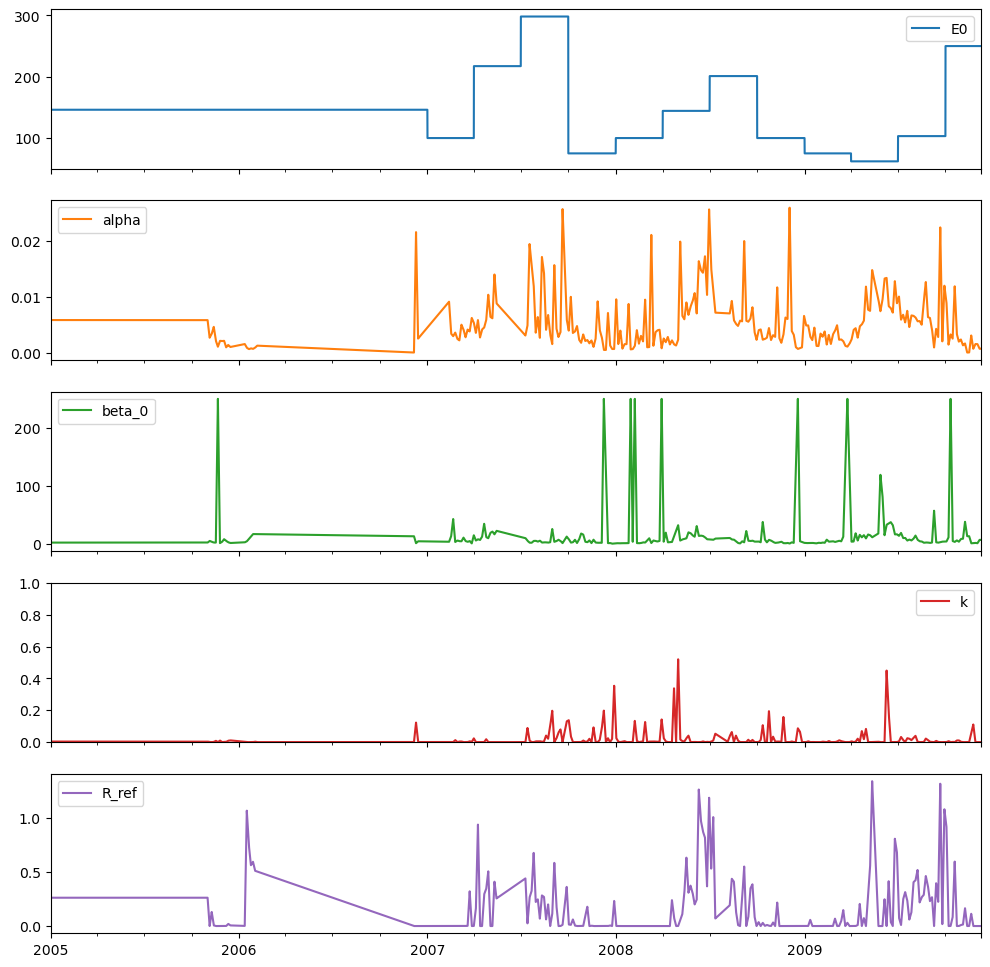

In [205]:
axs = lasslop_res.params.plot(subplots=True, figsize=(12, 12))
axs[-2].set_ylim(0, 1)

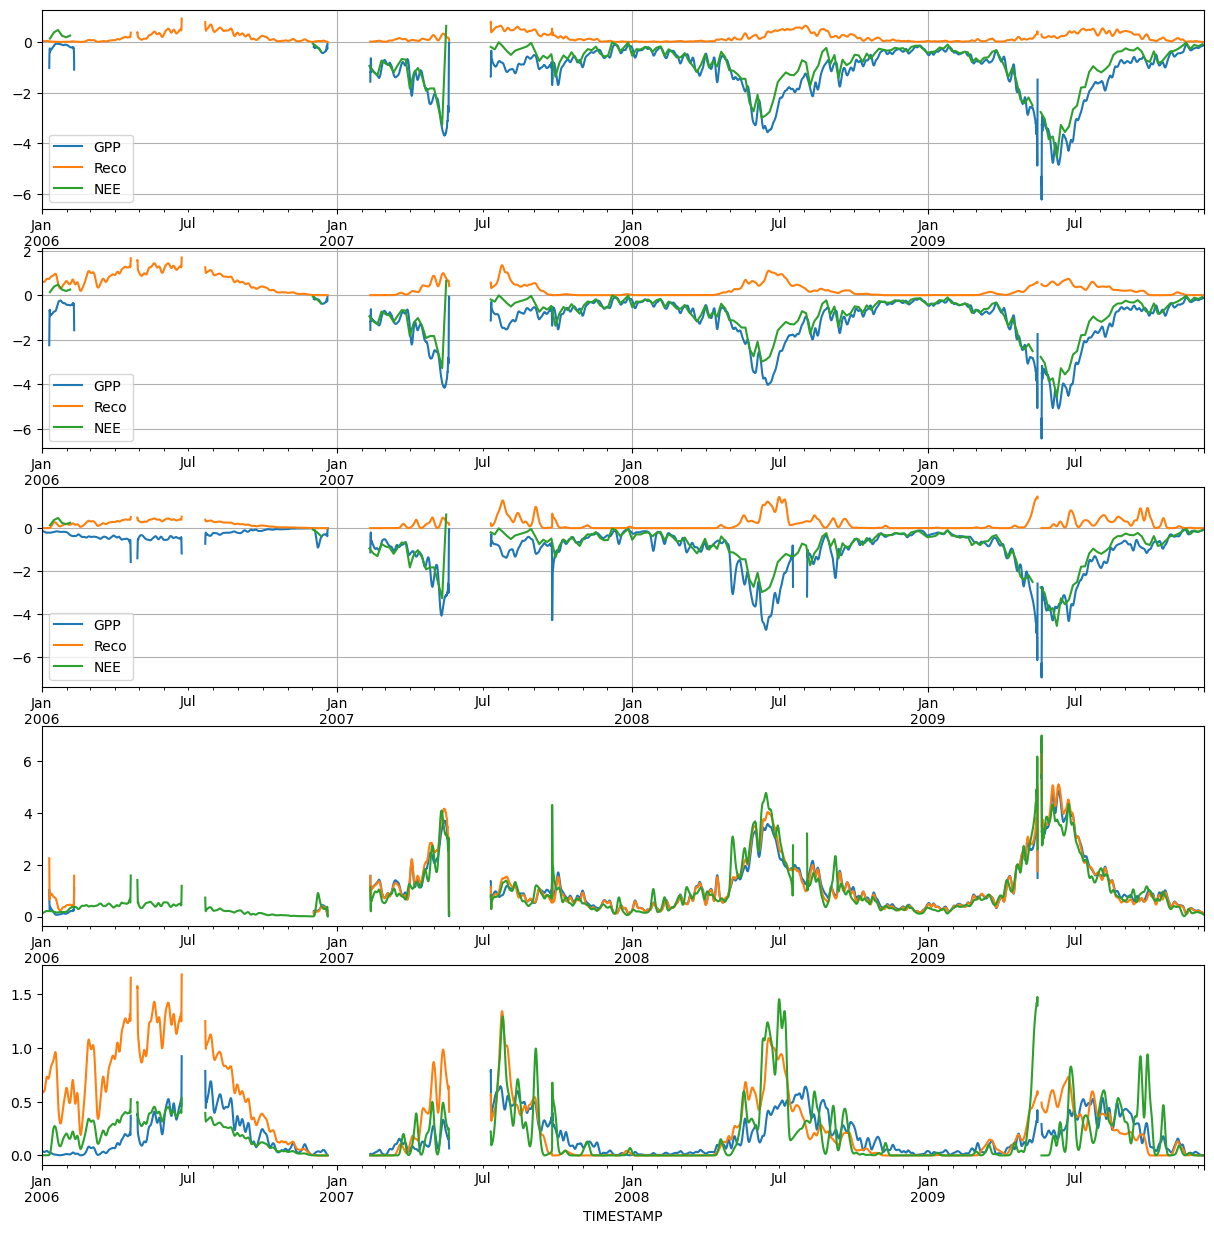

In [210]:
start, end = "2006-01-01", "2009-12-31"
fig, axs = plt.subplots(5, 1, figsize=(15,15))
(falge_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end]*[-1, 1]).plot(ax=axs[0])
(reich_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end]*[-1, 1]).plot(ax=axs[1])
(lasslop_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end]*[-1, 1]).plot(ax=axs[2])
(falge_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end, "GPP"]).plot(ax=axs[3])
(reich_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end, "GPP"]).plot(ax=axs[3])
(lasslop_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end, "GPP"]).plot(ax=axs[3])
(falge_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end, "Reco"]).plot(ax=axs[4])
(reich_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end, "Reco"]).plot(ax=axs[4])
(lasslop_partition.rolling(48*7, win_type="hamming", min_periods=3, center=True).mean().loc[start:end, "Reco"]).plot(ax=axs[4])

for ax in axs[:-2]:
    cpk.resample("5d").mean().loc[start:end, "NEE"].plot(label="NEE", ax=ax)
    ax.legend()
    ax.grid()
